## Кластеризация
### Цель работы
Освоить на практике основные приемы работы с самыми распространенными алгоритмами кластеризации.

План
1. Загрузите прилагающийся датасет. Проверьте его на чистоту, подготовьте к моделированию.
2. Разбейте датасет на три кластера методом К-средних. Оцените качество кластеризации по метрике WCSS.
3. Визуализируйте результат кластеризации. Выведите центры кластеров.
4. Выберите оптимальное количество кластеров методом локтя. Визуализируйте получившуюся кластеризацию.
5. Постройте кластеризацию с 8 кластерами. Как располагаются их центры и что это значит?
6. Нормализуйте датасет и повторите кластеризацию.
7. Постройте для наглядности кластеризацию только по двум признакам.
8. Постройте на том же датасете иерархическую кластеризацию.
9. Постройте на этих же данных кластеризацию методом DBSCAN.

Методические указания
Алгоритмы кластеризации, то есть разбиения точек выборки на пересекающиеся группы по схожести значения признаков, применяются для решения многих практических задач. Самая распространенная их них - это сегментация клиентов. Задача сегментации состоит в том, чтобы выделить среди клиентов организации какие-то заранее не известные группы таким образом, чтобы внутри каждой группы оказались похожие клиенты.

Посмотрим, как работают самые базовые алгоритмы кластеризации на примере как раз такой задачи. Скачаем датасет с данными о нескольких сотнях клиентов торговой компании:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

В этом наборе данных приведена базовая информация о клиентах, которая может быть полезна для категоризации их потребительского поведения:

In [2]:
df = pd.read_csv('data/mall_customers_clustering.csv', index_col=0)
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


In [4]:
df.Score.min(), df.Score.max(),

(0.01, 0.99)

Мы видим распределение вдоль этих двух численных признаков:

<Axes: xlabel='Income', ylabel='Score'>

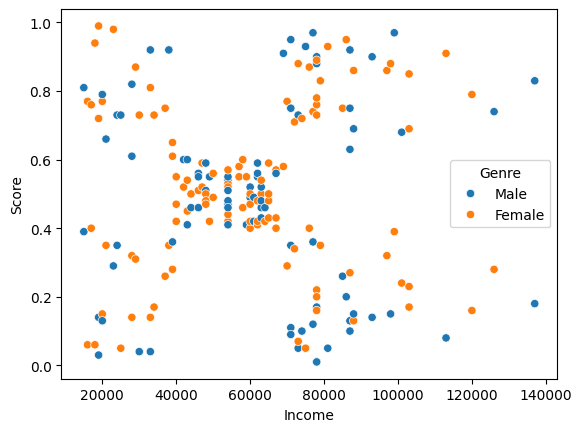

In [5]:
sns.scatterplot(x='Income' , y='Score',data=df , hue='Genre')

Всегда следует помнить, что в реальности данные более многомерны. В данном случае, мы видим только проекцию на плоскость. У нас есть еще одно численное измерение. Попробуйте самостоятельно изобразить датасет в других проекциях и представьте, как он выглядит в трехмерном пространстве.

Для дальнейшей работы нам понадобится произвести минимальную техническую предобработку данных:

In [6]:
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x)
X.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,19,15000,0.39,False,True
1,21,15000,0.81,False,True
2,20,16000,0.06,True,False
3,23,16000,0.77,True,False
4,31,17000,0.40,True,False


### Кластеризация К-средних

Теперь мы можем приступать к построению различных алгоритмов кластеризации на этих данных.
Для начала попробуем самый простой и распространенный алгоритм кластеризации - К-средних. Для его использования нужно импортировать соответствующий класс из пакета cluster библиотеки sklearn:

In [13]:
X.shape

(200, 5)

In [7]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42).fit(X)

D:\conda\envs\gz\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
y_kmeans = k_means.labels_
y_kmeans

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

разбиение на кластеры

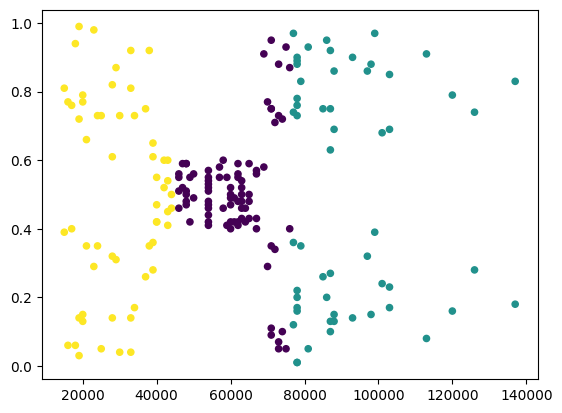

In [10]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')

Центроиды

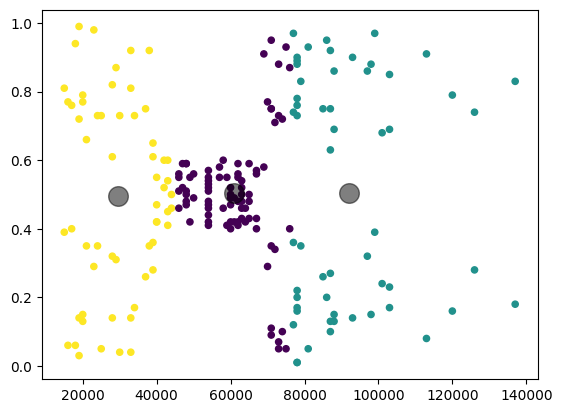

In [11]:
centers = k_means.cluster_centers_
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

In [12]:
k_means.cluster_centers_

array([[4.12790698e+01, 6.09069767e+04, 5.03372093e-01, 5.46511628e-01,
        4.53488372e-01],
       [3.69107143e+01, 9.21428571e+04, 5.05178571e-01, 5.17857143e-01,
        4.82142857e-01],
       [3.71206897e+01, 2.95517241e+04, 4.96896552e-01, 6.20689655e-01,
        3.79310345e-01]])

Очень просто убедиться, что визуализация построена корректно: центры кластеров соответствуют их очертаниям. В данном случае мы, как и задавали, получили три кластера. Но теперь перед нами встает вопрос, а правильное ли число кластеров мы выбрали? Для того,чтобы принимать решение, какое количество кластеров лучше или хуже, нам нужно воспользоваться метрикой качества. Мы возьмем самую распространенную - WCSS, или инерцию. Она уже рассчитана автоматически и помещена в свойство inertia_

Воспользуемся методом локтя для выбора оптимального количества кластеров. Для этого обучим модель с разным количеством, скажем, от 1 до 10, и для каждого количества выведем значение WCSS на графике:

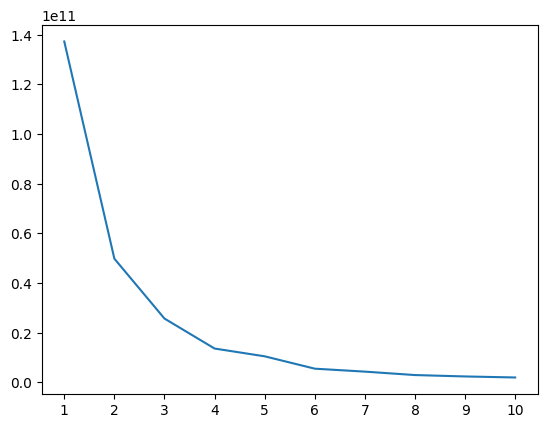

In [14]:
import warnings
warnings.filterwarnings('ignore')

wcss = []
for i in range(1, 11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X)
	wcss.append(k_means.inertia_)
    
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

Мы видим очень типичную картину: чем больше кластеров, тем меньше значение метрики WSCC. Но в начале она падает очень быстро, а при дальнейшем увеличении количества - начинает все больше выравниваться. Наша задача найти "излом" на этой кривой, то есть такое значение, после которого метрика продолжает падает уже значительно медленнее:
На некоторых кривых такой локоть более выражен, другие - более плавные, в отдельных случаях локтей может быть несколько. Метод локтя - не точная наука, а некоторый примерный ориентир. В данном случае, можно видеть, что 4 кажется неплохим выбором. Давайте построим кластеризацию на 4 кластера:

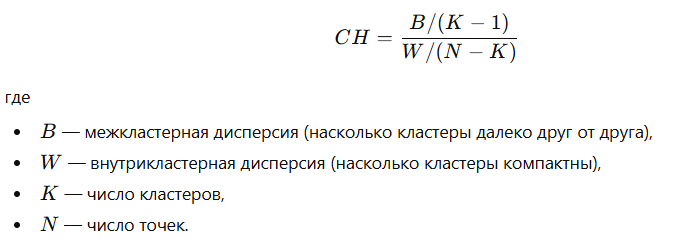

In [15]:
from IPython.display import Image, display

display(Image(filename='image.png'))

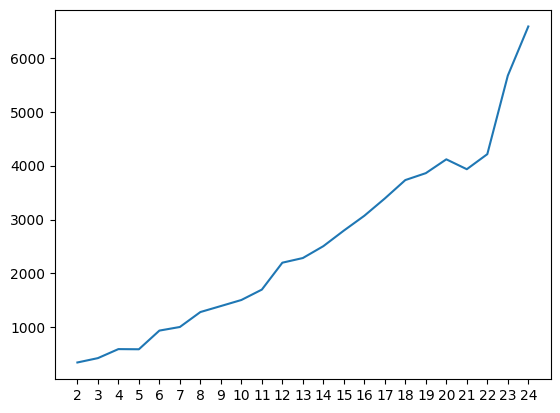

In [28]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import calinski_harabasz_score

ch_scores = []
for i in range(2, 25):
    k_means = KMeans(n_clusters=i, random_state=42)
    labels = k_means.fit_predict(X)

    ch_score = calinski_harabasz_score(X, labels)
    ch_scores.append(ch_score)

plt.plot(range(2,25),ch_scores)
plt.xticks(range(2,25))
_ = plt.show()



На некоторых кривых такой локоть более выражен, другие - более плавные, в отдельных случаях локтей может быть несколько. Метод локтя - не точная наука, а некоторый примерный ориентир. В данном случае, можно видеть, что 4 кажется неплохим выбором. Давайте построим кластеризацию на 4 кластера:

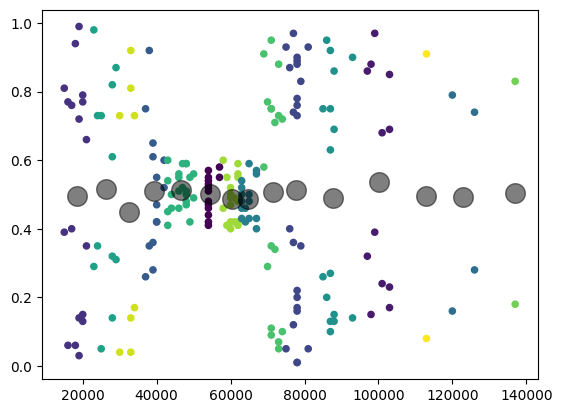

In [20]:
k_means = KMeans(n_clusters=15, random_state=42).fit(X)
y_kmeans = k_means.labels_
centers = k_means.cluster_centers_

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

Также изобразим ее на графике. Мы видим очень сходную картину (и она нас должна насторожить)
"На глаз" разделение данной выборки на 4 части не кажется оптимальным. Даже с учетом того, что мы видим датасет в проекции, кажется что при другом расположении центров кластеры были бы более компактными. Это странное поведение алгоритма. Давайте проверим его еще раз, значительно увеличив количество кластеров:

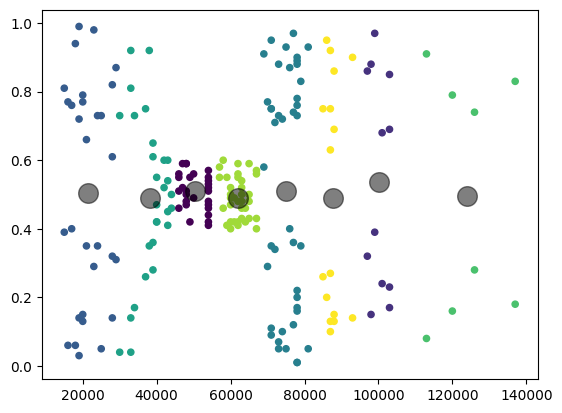

In [21]:
k_means = KMeans(n_clusters=8, random_state=42).fit(X)
y_kmeans = k_means.labels_
centers = k_means.cluster_centers_
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

Центры кластеров подозрительно всегда располагаются вдоль одной оси. И это не кажется оптимальным, когда мы смотрим на общее расположение точек. Если вы видите такое поведение, когда странное поведение выражается вдоль определенной оси, это должно вас навести на мысль о том, что что-то не так с масштабом.

И действительно, если мы взглянем на подписи осей, станет очевидным, что горизонтальная ось выражена в десятках тысяч, а вертикальная - в долях единицы. У нас типично ненормализованные данные. Давайте исправим эту ошибку и посмотрим, как это отразится на результатах кластеризации.

Нормализация признаков
Алгоритм К-средних, будучи метрическим методом, основывается на вычислении расстояний между точками выборки. Поэтому данные перед началом обучения обязательно надо нормировать. Мы воспользуемся стандартизацией, хотя здесь подошел бы и минимаксный способ.

In [22]:
x_sc = X.copy()
x_sc.Age /= x_sc.Age.max()
x_sc.Income /= x_sc.Income.max()
x_sc.Score /= x_sc.Score.max()
x_sc

,Age,Income,Score,Genre_Female,Genre_Male
0,0.271429,0.109489,0.393939,False,True
1,0.300000,0.109489,0.818182,False,True
2,0.285714,0.116788,0.060606,True,False
3,0.328571,0.116788,0.777778,True,False
4,0.442857,0.124088,0.404040,True,False
...,...,...,...,...,...
195,0.500000,0.875912,0.797980,True,False
196,0.642857,0.919708,0.282828,True,False
197,0.457143,0.919708,0.747475,False,True
198,0.457143,1.000000,0.181818,False,True


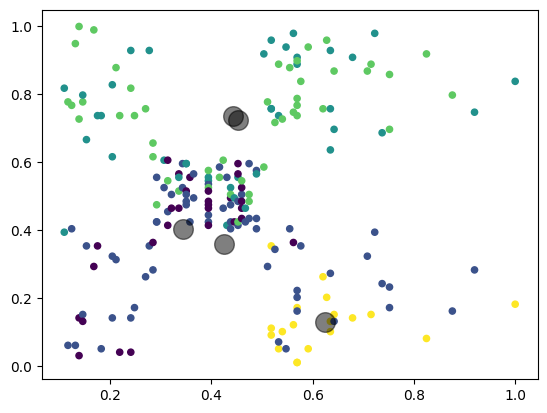

In [26]:
k_means = KMeans(n_clusters=5, random_state=42).fit(x_sc)
y_kmeans = k_means.labels_
centers = k_means.cluster_centers_
plt.scatter(x_sc.Income, x_sc.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)

На визуализации мы уже видим совершенно другую картину. Очевидно, нормализация данных очень сильно повлияла на работу алгоритма К-средних:

Главное, что центры кластеров уже не выстраиваются в линию параллельно одному из измерений. Однако, кластеры кажутся перемешанными. Это происходит от того, что мы смотрим на датасет в проекции. Поэтому при решении реальных задач не всегда можно опираться на визуализацию, а ориентироваться нужно в первую очередь на метрики.

Но для того, чтобы продемонстрировать то, насколько адекватно работает работает алгоритм K-средних, обучим его на плоском датасете, состоящим всего их двух признаков. Для этого удалим из матрицы лишние столбцы, оставив только те, которые выше мы использовали для визуализации:

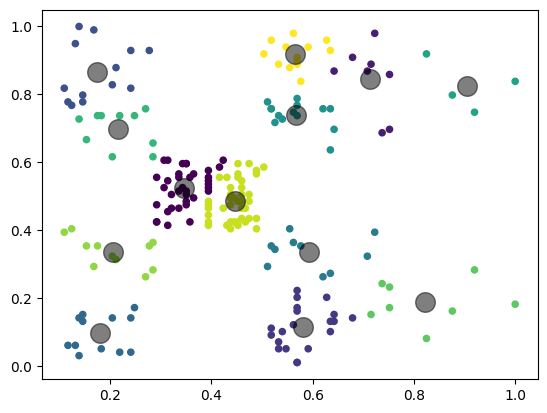

In [30]:
k_means = KMeans(n_clusters=13, random_state=42).fit(x_sc[['Income', 'Score']])
y_kmeans = k_means.labels_
centers = k_means.cluster_centers_
plt.scatter(x_sc.Income, x_sc.Score, c=y_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

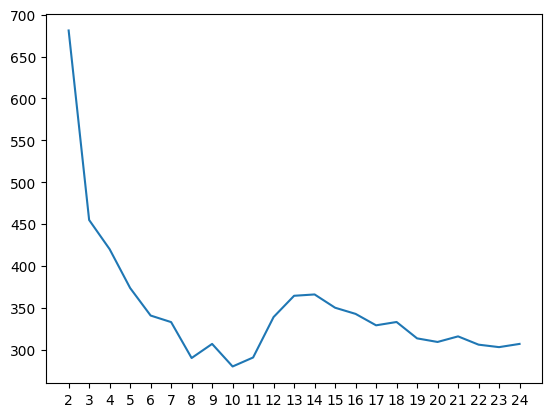

In [29]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import calinski_harabasz_score

ch_scores = []
for i in range(2, 25):
    k_means = KMeans(n_clusters=i, random_state=42)
    labels = k_means.fit_predict(x_sc)

    ch_score = calinski_harabasz_score(x_sc, labels)
    ch_scores.append(ch_score)

plt.plot(range(2,25),ch_scores)
plt.xticks(range(2,25))
_ = plt.show()


## Иерархическая кластеризация

Алгоритм К-средних работает вполне удовлетворительно на тех данных, которые мы анализировали в предыдущей части. Но есть и другие алгоритмы кластеризации, которые имеют свои особенности. Одним тех, которые часто требуются является алгоритм агломеративной кластеризации. Его особенность в том, что это иерархический метод. Он позволяет не только разбить выборку на определенное число кластеров, но и построить таксономию - то есть последовательное объединение кластеров также по принципу сходства.

Работа с моделью агломеративной кластеризации по интерфейсу полностью аналогична:

In [31]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(x_sc)

При создании модели ей передается два аргумента, причем они работают альтернативно. Вы можете задать определенное количество кластеров, тогда порог игнорируется (задается как None), но так мы уже делали. Поэтому воспользуемся вторым "режимом" работы - зададим порог функции расстояния, тогда количество кластеров алгоритм будет выбирать сам и нам нужно задать в этом параметре None.

Для того, чтобы понять, как работает иерархическая кластеризация, мы построим ее визуализацию в виде дерева. Оно покажет как именно, в каком порядке кластеры объединяются. Такая диаграмма называется дендрограммой, и для ее построения существует специальная функция в библиотеке scipy:

In [32]:
from scipy.cluster.hierarchy import dendrogram

Для построения дендрограммы в эту функцию нужно передать марицу связности в специальном виде. Мы используем готовый сниппет кода, который принимает на вход объект обученной модели агломерационной кластеризации и строит по нему дендрограмму:

In [33]:
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)
    #print(linkage_matrix)

Мы приведем этот код без комментариев. Но самостоятельно рекомендуем при его выполнении вывести матрицу связности и разобраться, как она устроена.

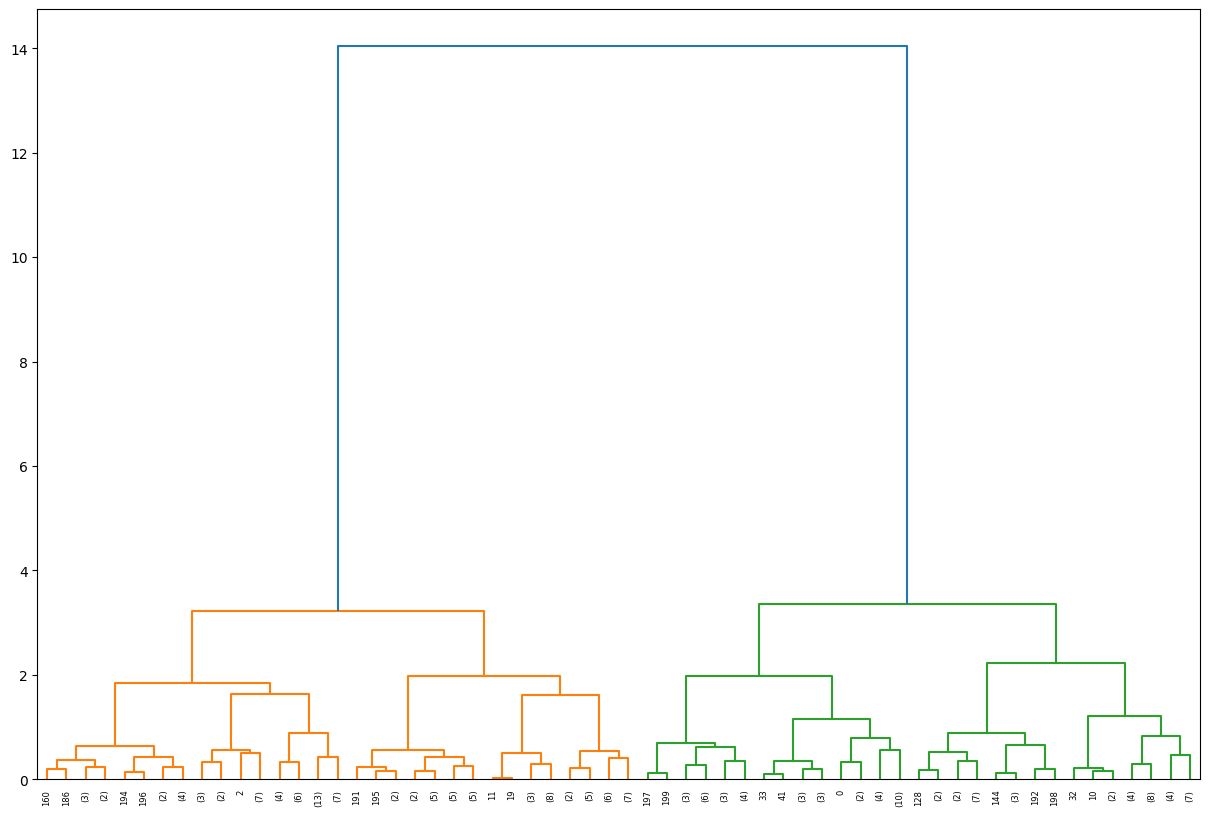

In [34]:
import numpy as np
plt.figure(figsize=(15, 10))
plot_dendrogram(model, truncate_mode="level", p=5)

Мы получаем следующее визуальное представление работы обученного алгоритма иерархической кластеризации:
По оси Y в этом коде отображаются дистанции (расстояния), при которых происходят слияния кластеров во время иерархической агломеративной кластеризации.

Разберемся, как устроен это график. По вертикали на нем отложена мера расстояния между объектами или кластерами. По горизонтали - объекты датасета. Соответственно, на уровне самих объектов расстояние между ними равно нулю (расстояние от объекта до самого себя). Ближайшие объекты объединяются в группу, что отражается на дендрограмме характерной формой с перемычкой на том вертикальном уровне, который соответствует расстоянию между объектами. Затем эти группы объединяются между собой, и так до тех пор, пока вся выборка не будет объединена.

Соответственно, интерес представляет именно порядок, в котором разные объекты будут объединяться. Чем две точки выборки дальше друг от друга, тем позже они попадут в один кластер, и тем выше на дендрограмме будет это объединение.

Соответственно, мы можем как бы "обрезать" это дендрограмму на определенном уровне. Тогда точки, которые попали в одну группу будут "зачислены" в общий кластер. Чем ниже мы обрезаем дендрограмму, тем мельче будут кластеры, но больше их количество. Именно за этот уровень и отвечает аргумент distance_threshold конструктора класса агломеративной кластеризации.

Либо, мы можем исходить, как раньше, из желаемого количества кластеров. Тогда алгоритм "обрежет" дендрограмму на таком уровне, чтобы получилось необходимое количество групп. Построим кластеризацию на нашем нормализованном датасете:

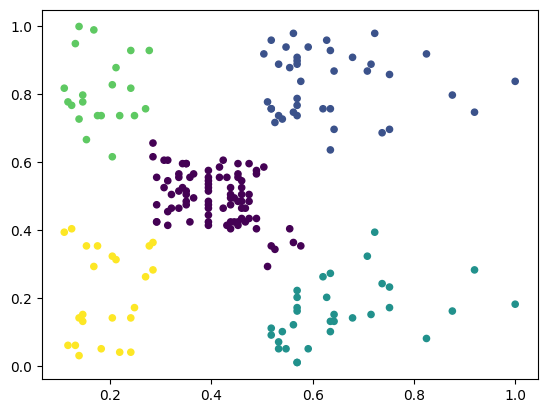

In [41]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(x_sc[['Income', 'Score']])
y_agg = agg_clustering.labels_

plt.scatter(x_sc.Income, x_sc.Score, c=y_agg, s=20, cmap='viridis')

## DBSCAN

Еще один алгоритм кластеризации, который необходимо разобрать на практике, потому, что он использует совершенно другой подход - DBSCAN. Он оценивает плотность расположения точек в окрестностях заданной. Попробуем построить его на тех же данных (для наглядности, будем использовать плоские данные):

In [45]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=3).fit(x_sc)
y_db = db.labels_
y_db

array([0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0], dtype=int64)

У конструктора данного класса два обязательных аргумента: eps - максимальный радиус вокруг точки, попадание в который считается соседством; и min_samples - количество соседних точек, которых достаточно для признания данной точки внутренней. Оба параметра оказывают существенное влияние на результат кластеризации. Они подбираются эмпирически.

Обычно, эмпирический выбора гиперпараметров модели обучения опирается на значение метрики качества. Так мы делали в предыдущем пункте, в методе локтя. Но сейчас покажем другой подход. Можно мониторить количество кластеров и точек шума, которые определяет алгоритм при данных значениях гиперпараметров. Эти данные можно вычислять так:

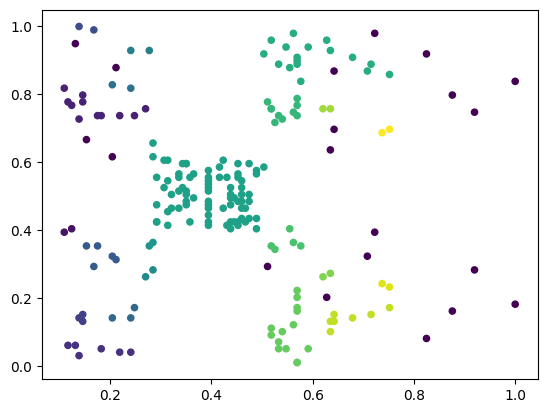

In [48]:
db = DBSCAN(eps=.05, min_samples=2).fit(x_sc[['Income', 'Score']])
y_db = db.labels_

plt.scatter(x_sc.Income, x_sc.Score, c=y_db, s=20, cmap='viridis')

In [49]:
from IPython.display import Image
from IPython.core.display import HTML 
Image(url= "clusters.jpg")